# 배송 경험과 리뷰점수 간의 통계 검증

## 분석 목적

본 분석은 물류 허브 선정 분석과 퍼널/코호트 분석에 들어가기 전에, 전처리 완료된 Olist 주문 데이터를 활용하여 배송 경험과 고객 리뷰점수 간의 관계를 통계적으로 검증하는 것을 목표로 한다.

특히 다음 질문에 집중한다.

1. 배송이 늦어질수록 리뷰점수는 낮아지는가?
2. 배송 예정일보다 실제 배송일이 늦어진 경우 리뷰점수는 유의하게 낮은가?
3. 배송 예정일보다 빠르게 도착한 주문은 리뷰점수가 더 높은가?
4. 1점 리뷰와 5점 리뷰는 배송 경험 측면에서 어떤 차이가 있는가?
5. 극단 리뷰점수인 1점과 5점이 전체 만족도 해석에 어떤 영향을 주는가?

이 분석은 이후 물류 허브 선정, 배송 개선 전략, 고객 만족도 분석의 기초 근거로 활용된다.

In [2]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")

df.shape

(108581, 68)

## 1. 주문 단위 분석 테이블 생성

현재 데이터는 item level 데이터이므로 하나의 주문이 여러 행으로 반복될 수 있다.

리뷰점수, 배송기간, 배송 예정일, 실제 배송일은 주문 단위 변수이기 때문에 `order_id` 기준으로 집계한 뒤 통계검정을 수행한다.

배송 지연일은 다음과 같이 정의한다.

`배송 지연일 = 실제 배송일 - 배송 예정일`

- 음수: 예정일보다 조기 도착
- 0: 예정일 당일 도착
- 양수: 예정일보다 지연 도착

In [3]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

order_df = df.groupby("order_id", as_index=False).agg(
    order_purchase_timestamp=("order_purchase_timestamp", "first"),
    order_delivered_customer_date=("order_delivered_customer_date", "first"),
    order_estimated_delivery_date=("order_estimated_delivery_date", "first"),
    delivery_days_clean=("delivery_days_clean", "first"),
    is_late=("is_late", "first"),
    review_score_mean=("review_score_mean", "first"),
    payment_value_total=("payment_value_total", "first"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    customer_region=("customer_region", "first"),
    customer_state=("customer_state", "first"),
    seller_region=("seller_region", "first"),
    seller_state=("seller_state", "first"),
    delivery_route=("delivery_route", "first")
)

order_df["delivery_gap_days"] = (
    order_df["order_delivered_customer_date"] -
    order_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

order_df["delivery_gap_days"] = np.floor(order_df["delivery_gap_days"])
order_df["is_delay"] = order_df["delivery_gap_days"] > 0

order_df["review_score_int"] = order_df["review_score_mean"].round().astype("Int64")

order_df = order_df.dropna(subset=[
    "delivery_gap_days",
    "review_score_mean",
    "review_score_int"
]).copy()

order_df.shape

(94443, 18)

In [4]:
order_df[[
    "delivery_gap_days",
    "delivery_days_clean",
    "review_score_mean",
    "is_delay"
]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
delivery_gap_days,94443.0,-11.861567,10.127626,-147.0,-36.0,-26.0,-17.0,-12.0,-7.0,3.0,18.0,188.0
delivery_days_clean,94443.0,12.110829,9.491174,0.0,1.0,3.0,6.0,10.0,15.0,29.0,45.0,208.0
review_score_mean,94443.0,4.154089,1.284945,1.0,1.0,1.0,4.0,5.0,5.0,5.0,5.0,5.0


# 가설 1. 배송 지연일이 증가할수록 리뷰점수는 낮아지는가?

## 분석 목적

배송 예정일 대비 실제 배송일의 차이가 고객 리뷰점수에 미치는 영향을 확인한다.

기존 시각화에서 배송 지연일이 0일을 넘어간 이후 평균 리뷰점수가 급격히 하락하는 패턴이 확인되었다.

## 가설

- H0: 배송 지연일과 리뷰점수 간 상관관계는 없다.
- H1: 배송 지연일과 리뷰점수 간 상관관계가 있다.

## 사용 검정

- Pearson 상관분석
- Spearman 상관분석
- 단순 선형회귀

리뷰점수는 1~5점의 순서형 변수이고 배송 지연일에는 이상치가 존재할 수 있으므로 Spearman 상관분석을 우선적으로 해석한다.

In [7]:
h1_df = order_df[["delivery_gap_days", "review_score_mean"]].dropna()

pearson_result = stats.pearsonr(
    h1_df["delivery_gap_days"],
    h1_df["review_score_mean"]
)

spearman_result = stats.spearmanr(
    h1_df["delivery_gap_days"],
    h1_df["review_score_mean"]
)

print("Pearson correlation:", pearson_result)
print("Spearman correlation:", spearman_result)

Pearson correlation: PearsonRResult(statistic=np.float64(-0.2694257130646638), pvalue=np.float64(0.0))
Spearman correlation: SignificanceResult(statistic=np.float64(-0.17816048163163015), pvalue=np.float64(0.0))


In [8]:
# scipy를 활용한 단순 선형회귀

reg_result = stats.linregress(
    h1_df["delivery_gap_days"],
    h1_df["review_score_mean"]
)

print("slope:", reg_result.slope)
print("intercept:", reg_result.intercept)
print("r-value:", reg_result.rvalue)
print("p-value:", reg_result.pvalue)
print("std_err:", reg_result.stderr)

slope: -0.034183451412858314
intercept: 3.748620106191284
r-value: -0.26942571306466406
p-value: 0.0
std_err: 0.00039758722147226146


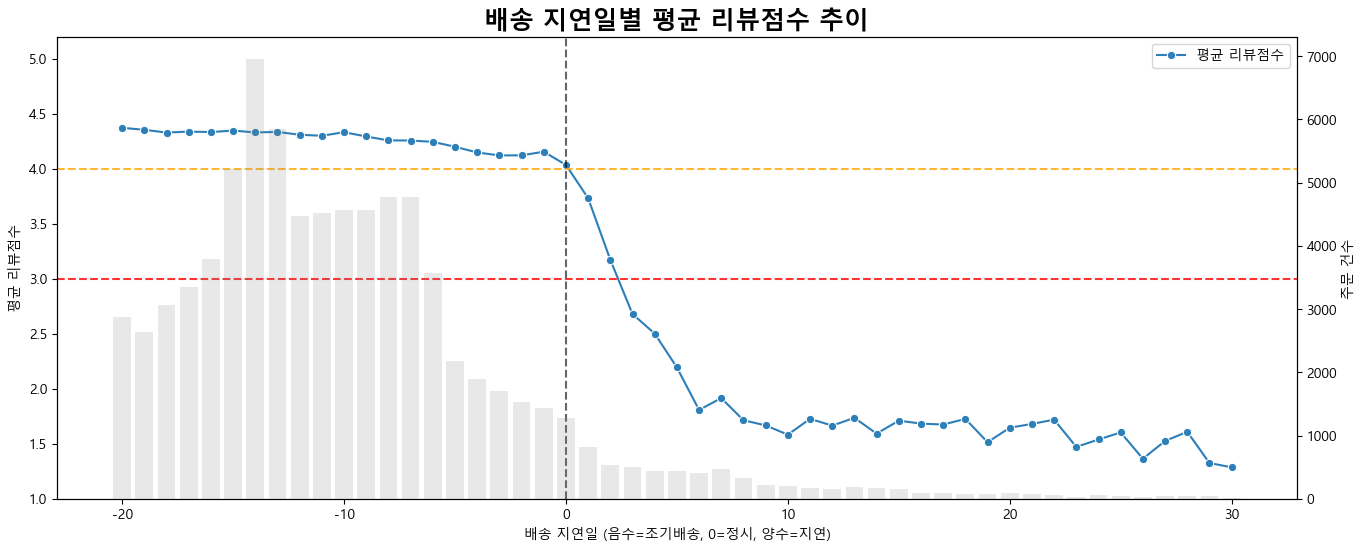

In [9]:
# 시각화: 배송 지연일별 평균 리뷰점수 추이

gap_summary = order_df.groupby("delivery_gap_days").agg(
    order_count=("order_id", "count"),
    mean_review=("review_score_mean", "mean")
).reset_index()

gap_summary_plot = gap_summary[
    gap_summary["delivery_gap_days"].between(-20, 30)
]

plt.figure(figsize=(16, 6))

ax1 = plt.gca()
ax2 = ax1.twinx()

sns.lineplot(
    data=gap_summary_plot,
    x="delivery_gap_days",
    y="mean_review",
    marker="o",
    ax=ax1,
    color="#2c7fb8",
    label="평균 리뷰점수"
)

ax2.bar(
    gap_summary_plot["delivery_gap_days"],
    gap_summary_plot["order_count"],
    alpha=0.18,
    color="gray",
    label="주문 건수"
)

ax1.axvline(0, color="black", linestyle="--", alpha=0.6)
ax1.axhline(4, color="orange", linestyle="--", alpha=0.8)
ax1.axhline(3, color="red", linestyle="--", alpha=0.8)

ax1.set_title("배송 지연일별 평균 리뷰점수 추이", fontsize=18, weight="bold")
ax1.set_xlabel("배송 지연일 (음수=조기배송, 0=정시, 양수=지연)")
ax1.set_ylabel("평균 리뷰점수")
ax2.set_ylabel("주문 건수")

ax1.set_ylim(1, 5.2)

plt.show()

## 결과 해석 예시

Spearman 상관계수가 음수이고 p-value가 0.05보다 작다면, 배송 예정일 대비 실제 배송이 늦어질수록 리뷰점수가 낮아지는 경향이 통계적으로 유의하다고 해석한다.

회귀분석에서 `delivery_gap_days`의 계수가 음수라면, 지연일이 1일 증가할 때 평균 리뷰점수가 감소한다는 의미이다.

이는 고객 만족도 관리에서 단순한 총 배송기간보다 “예정일 대비 지연”이 중요한 변수임을 보여준다.

# 가설 2. 비지연 주문과 지연 주문의 리뷰점수 분포는 다른가?

## 분석 목적

비지연 주문과 지연 주문의 1~5점 리뷰 분포가 통계적으로 다른지 확인한다.

기존 시각화에서 비지연 주문은 5점 리뷰 비중이 높고, 지연 주문은 1점 리뷰 비중이 높게 나타났다.

## 가설

- H0: 비지연 주문과 지연 주문의 리뷰점수 분포는 동일하다.
- H1: 비지연 주문과 지연 주문의 리뷰점수 분포는 다르다.

## 사용 검정

- 카이제곱 독립성 검정
- 효과크기: Cramer's V

`is_delay`와 `review_score_int`는 범주형 변수이므로 카이제곱 검정을 사용한다.

In [10]:
delay_score_table = pd.crosstab(
    order_df["is_delay"],
    order_df["review_score_int"]
)

display(delay_score_table)

chi2, p, dof, expected = stats.chi2_contingency(delay_score_table)

n = delay_score_table.to_numpy().sum()
r, c = delay_score_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

review_score_int,1,2,3,4,5
is_delay,,,,,
False,5794,2357,7147,18023,54766
True,3415,558,686,647,1050


Chi-square statistic: 16690.992956765356
p-value: 0.0
degrees of freedom: 4
Cramer's V: 0.42039370078690846


In [11]:
delay_score_rate = delay_score_table.div(delay_score_table.sum(axis=1), axis=0)

display((delay_score_rate * 100).round(2))

review_score_int,1,2,3,4,5
is_delay,,,,,
False,6.58,2.68,8.11,20.46,62.17
True,53.73,8.78,10.79,10.18,16.52


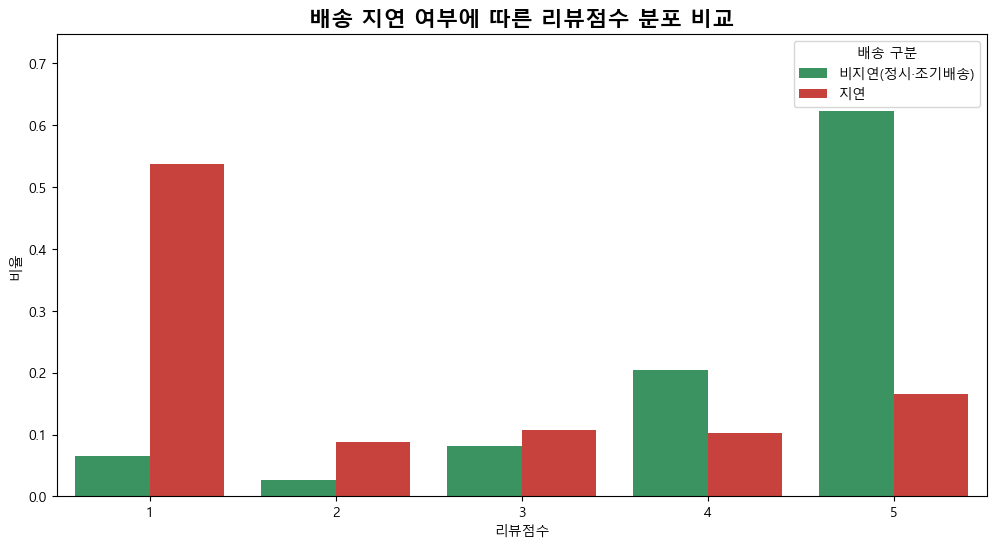

In [12]:
# 시각화: 지연 여부별 리뷰점수 분포

plot_df = delay_score_rate.reset_index().melt(
    id_vars="is_delay",
    var_name="review_score",
    value_name="rate"
)

plot_df["delay_label"] = plot_df["is_delay"].map({
    False: "비지연(정시·조기배송)",
    True: "지연"
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="review_score",
    y="rate",
    hue="delay_label",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("배송 지연 여부에 따른 리뷰점수 분포 비교", fontsize=16, weight="bold")
plt.xlabel("리뷰점수")
plt.ylabel("비율")
plt.ylim(0, plot_df["rate"].max() * 1.2)
plt.legend(title="배송 구분")

plt.show()

## 결과 해석 예시

p-value가 0.05보다 작다면 배송 지연 여부와 리뷰점수 분포는 독립이 아니라고 판단한다.

즉, 지연 여부에 따라 1~5점 리뷰 분포가 통계적으로 다르다.

지연 주문에서 1점 리뷰 비중이 높고 5점 리뷰 비중이 낮다면, 배송 지연은 고객 불만족을 크게 증가시키는 요인으로 해석할 수 있다.

# 가설 3. 배송 지연 구간별 리뷰점수 분포는 다른가?

## 분석 목적

배송 지연일을 구간화했을 때, 지연 구간이 길어질수록 리뷰점수 분포가 부정적으로 이동하는지 검증한다.

## 배송 지연 구간

- 조기배송
- 정시(0일)
- 1~3일 지연
- 4~7일 지연
- 8~14일 지연
- 15~30일 지연
- 30일 초과 지연

## 가설

- H0: 배송 지연 구간과 리뷰점수 분포는 독립이다.
- H1: 배송 지연 구간과 리뷰점수 분포는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정
- 효과크기: Cramer's V

In [13]:
bins = [-np.inf, -1, 0, 3, 7, 14, 30, np.inf]
labels = [
    "조기배송",
    "정시(0일)",
    "1~3일",
    "4~7일",
    "8~14일",
    "15~30일",
    "30일 초과"
]

order_df["delay_bin"] = pd.cut(
    order_df["delivery_gap_days"],
    bins=bins,
    labels=labels,
    right=True
)

delay_bin_table = pd.crosstab(
    order_df["delay_bin"],
    order_df["review_score_int"]
)

display(delay_bin_table)

chi2, p, dof, expected = stats.chi2_contingency(delay_bin_table)

n = delay_bin_table.to_numpy().sum()
r, c = delay_bin_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

review_score_int,1,2,3,4,5
delay_bin,,,,,
조기배송,5688,2306,6970,17727,54125
정시(0일),106,51,177,296,641
1~3일,464,131,268,369,610
4~7일,1017,159,172,147,245
8~14일,1019,139,126,61,99
15~30일,708,113,92,40,51
30일 초과,207,16,28,30,45


Chi-square statistic: 19484.541864728377
p-value: 0.0
degrees of freedom: 24
Cramer's V: 0.22710684115207752


In [14]:
delay_bin_rate = delay_bin_table.div(delay_bin_table.sum(axis=1), axis=0)

display((delay_bin_rate * 100).round(2))

review_score_int,1,2,3,4,5
delay_bin,,,,,
조기배송,6.55,2.66,8.03,20.42,62.34
정시(0일),8.34,4.01,13.93,23.29,50.43
1~3일,25.19,7.11,14.55,20.03,33.12
4~7일,58.45,9.14,9.89,8.45,14.08
8~14일,70.57,9.63,8.73,4.22,6.86
15~30일,70.52,11.25,9.16,3.98,5.08
30일 초과,63.50,4.91,8.59,9.20,13.80


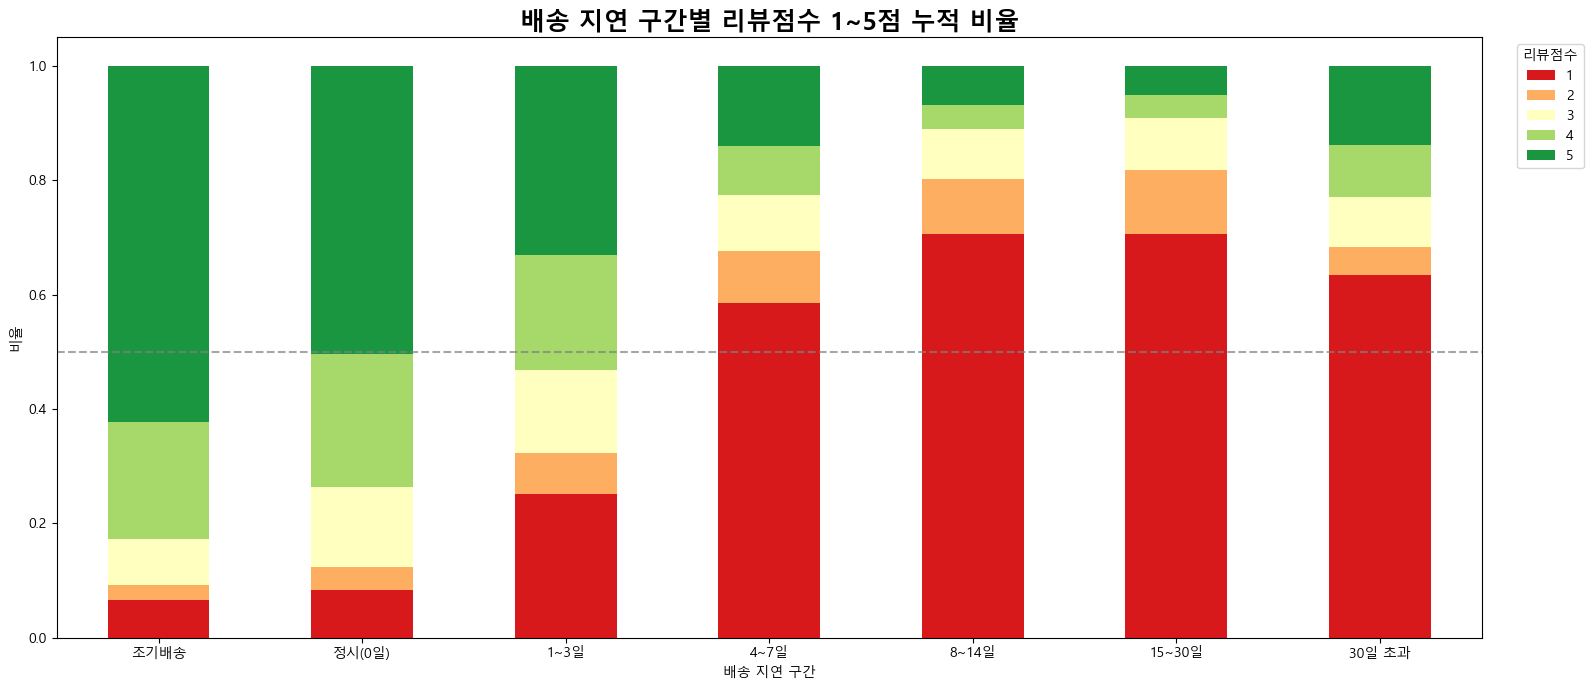

In [15]:
# 시각화: 배송 지연 구간별 리뷰점수 누적 비율

delay_bin_rate_plot = delay_bin_rate.copy()

delay_bin_rate_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    color=["#d7191c", "#fdae61", "#ffffbf", "#a6d96a", "#1a9641"]
)

plt.title("배송 지연 구간별 리뷰점수 1~5점 누적 비율", fontsize=18, weight="bold")
plt.xlabel("배송 지연 구간")
plt.ylabel("비율")
plt.legend(title="리뷰점수", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 결과 해석 예시

p-value가 0.05보다 작다면 배송 지연 구간에 따라 리뷰점수 분포가 통계적으로 다르다고 해석한다.

특히 지연 구간이 길어질수록 1점 리뷰 비율이 증가하고 5점 리뷰 비율이 감소한다면, 고객 만족도는 배송 지연 정도에 따라 단계적으로 악화된다고 볼 수 있다.

이는 배송 지연이 평균 점수뿐 아니라 리뷰점수 분포 전체를 부정적으로 이동시킨다는 근거가 된다.

# 가설 4. 배송 지연 구간별 평균 리뷰점수는 다른가?

## 분석 목적

배송 지연 구간별 평균 리뷰점수 차이가 통계적으로 유의한지 검증한다.

기존 시각화에서 평균 리뷰점수는 조기배송과 정시배송에서는 높게 유지되다가, 지연 구간으로 갈수록 하락하는 패턴을 보였다.

## 가설

- H0: 배송 지연 구간별 평균 리뷰점수는 같다.
- H1: 배송 지연 구간 중 적어도 하나의 평균 리뷰점수는 다르다.

## 사용 검정

- ANOVA
- Kruskal-Wallis 검정

리뷰점수는 정규분포를 따르기 어렵고 순서형 성격이 있으므로 Kruskal-Wallis 검정을 우선적으로 해석한다.

In [16]:
h4_df = order_df[["delay_bin", "review_score_mean"]].dropna()

delay_bin_summary = h4_df.groupby("delay_bin", observed=True)["review_score_mean"].agg(
    ["count", "mean", "median", "std"]
)

display(delay_bin_summary)

groups = [
    group["review_score_mean"].values
    for _, group in h4_df.groupby("delay_bin", observed=True)
]

anova_result = stats.f_oneway(*groups)
kruskal_result = stats.kruskal(*groups)

print("ANOVA:", anova_result)
print("Kruskal-Wallis:", kruskal_result)

,count,mean,median,std
delay_bin,,,,
조기배송,86816,4.293767,5.0,1.145972
정시(0일),1271,4.035012,5.0,1.246631
1~3일,1842,3.287731,4.0,1.588166
4~7일,1740,2.105460,1.0,1.509201
8~14일,1444,1.672438,1.0,1.213679
15~30일,1004,1.619024,1.0,1.127039
30일 초과,326,2.050613,1.0,1.528614


ANOVA: F_onewayResult(statistic=np.float64(3323.3223861267948), pvalue=np.float64(0.0))
Kruskal-Wallis: KruskalResult(statistic=np.float64(10136.168934480247), pvalue=np.float64(0.0))


C:\Users\yiho1\AppData\Local\Temp\ipykernel_33704\1070061264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


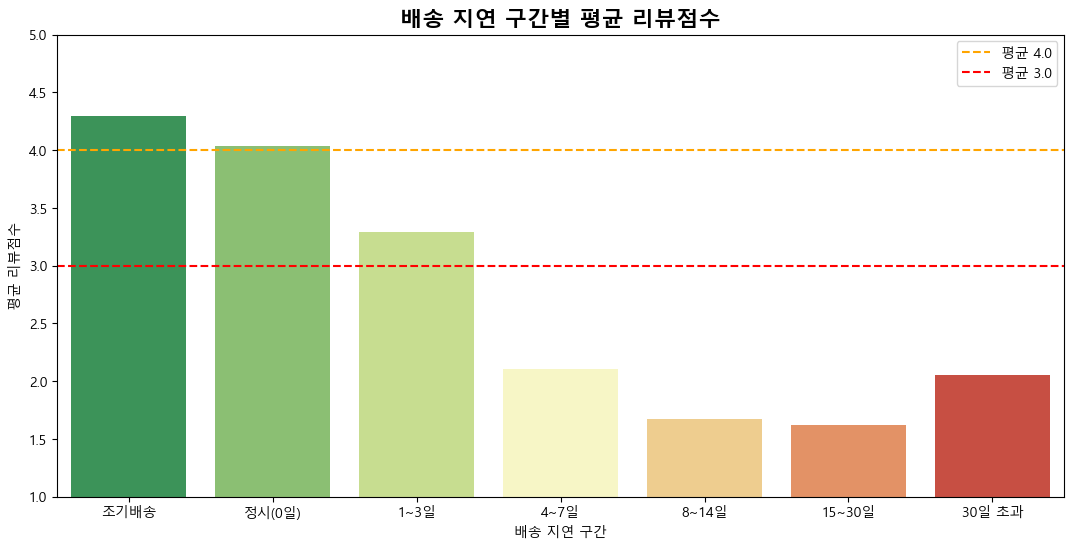

In [17]:
# 시각화: 배송 지연 구간별 평균 리뷰점수

summary_plot = delay_bin_summary.reset_index()

plt.figure(figsize=(13, 6))

sns.barplot(
    data=summary_plot,
    x="delay_bin",
    y="mean",
    palette="RdYlGn_r"
)

plt.axhline(4, color="orange", linestyle="--", label="평균 4.0")
plt.axhline(3, color="red", linestyle="--", label="평균 3.0")

plt.title("배송 지연 구간별 평균 리뷰점수", fontsize=16, weight="bold")
plt.xlabel("배송 지연 구간")
plt.ylabel("평균 리뷰점수")
plt.ylim(1, 5)
plt.legend()

plt.show()

## 결과 해석 예시

Kruskal-Wallis 검정의 p-value가 0.05보다 작다면 배송 지연 구간별 리뷰점수 분포에 유의미한 차이가 있다고 판단한다.

평균 또는 중앙값이 조기배송, 정시배송, 1~3일 지연, 4~7일 지연 순으로 하락한다면, 배송 지연이 누적될수록 고객 만족도가 악화된다는 해석이 가능하다.

# 가설 5. 배송 지연은 1점 리뷰 발생 비율을 높이는가?

## 분석 목적

지연 배송 주문에서 1점 리뷰 비율이 높아지는지 검증한다.

이는 배송 지연이 고객 불만족을 유발하는 핵심 요인인지 확인하기 위한 분석이다.

기존 시각화에서 지연 구간으로 갈수록 1점 리뷰 비율이 크게 증가하는 패턴이 확인되었으므로, 이를 통계적으로 검증한다.

## 가설

- H0: 배송 지연 여부와 1점 리뷰 여부는 독립이다.
- H1: 배송 지연 여부와 1점 리뷰 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

`is_delay`는 배송 지연 여부를 나타내는 범주형 변수이고, `is_one_star`는 리뷰점수가 1점인지 여부를 나타내는 범주형 변수이다.

따라서 두 범주형 변수 간의 관련성을 검정하기 위해 카이제곱 독립성 검정을 사용한다.

In [21]:
# 1점 리뷰 여부 생성
order_df["is_one_star"] = order_df["review_score_int"] == 1

# 배송 지연 여부와 1점 리뷰 여부의 교차표
one_star_table = pd.crosstab(
    order_df["is_delay"],
    order_df["is_one_star"]
)

display(one_star_table)

is_one_star,False,True
is_delay,,
False,82293,5794
True,2941,3415


In [22]:
# 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(one_star_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

# 효과크기: Phi coefficient
# 2x2 교차표에서는 Cramer's V와 Phi가 동일하게 해석 가능
n = one_star_table.to_numpy().sum()
phi = np.sqrt(chi2 / n)

print("Phi coefficient:", phi)

Chi-square statistic: 14971.652645469676
p-value: 0.0
degrees of freedom: 1
Phi coefficient: 0.39815299253471736


In [23]:
# 배송 지연 여부별 1점 리뷰 비율
one_star_rate = order_df.groupby("is_delay")["is_one_star"].agg(
    count="count",
    one_star_rate="mean"
)

one_star_rate["one_star_rate_pct"] = one_star_rate["one_star_rate"] * 100

display(one_star_rate)

,count,one_star_rate,one_star_rate_pct
is_delay,,,
False,88087,0.065776,6.577588
True,6356,0.537288,53.72876


C:\Users\yiho1\AppData\Local\Temp\ipykernel_33704\1970864730.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


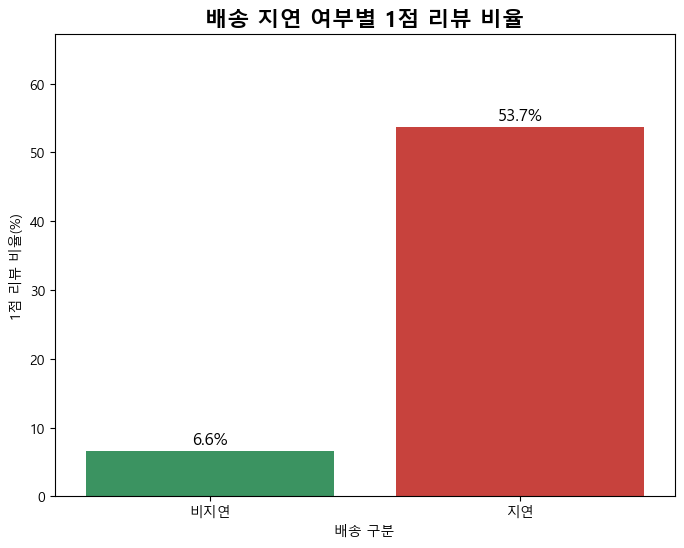

In [24]:
# 시각화: 배송 지연 여부별 1점 리뷰 비율

one_star_plot = one_star_rate.reset_index()
one_star_plot["delay_label"] = one_star_plot["is_delay"].map({
    False: "비지연",
    True: "지연"
})

plt.figure(figsize=(8, 6))

sns.barplot(
    data=one_star_plot,
    x="delay_label",
    y="one_star_rate_pct",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("배송 지연 여부별 1점 리뷰 비율", fontsize=16, weight="bold")
plt.xlabel("배송 구분")
plt.ylabel("1점 리뷰 비율(%)")

for i, row in one_star_plot.iterrows():
    plt.text(
        i,
        row["one_star_rate_pct"] + 1,
        f'{row["one_star_rate_pct"]:.1f}%',
        ha="center",
        fontsize=12
    )

plt.ylim(0, one_star_plot["one_star_rate_pct"].max() * 1.25)
plt.show()

## 결과 해석 예시

카이제곱 독립성 검정 결과 p-value가 0.05보다 작다면, 배송 지연 여부와 1점 리뷰 발생 여부는 서로 독립이 아니라고 판단한다.

즉, 배송 지연 여부에 따라 1점 리뷰 발생 비율이 통계적으로 유의하게 달라진다.

만약 지연 주문의 1점 리뷰 비율이 비지연 주문보다 높다면, 배송 지연은 고객 불만족 리뷰를 증가시키는 요인으로 해석할 수 있다.

Phi coefficient는 효과크기를 나타낸다. 값이 클수록 배송 지연 여부와 1점 리뷰 발생 여부 간 관련성이 강하다는 의미이다.

따라서 본 결과는 배송 지연이 단순히 평균 리뷰점수를 낮추는 데 그치지 않고, 극단적인 불만족 평가인 1점 리뷰 발생 비율을 높일 수 있음을 시사한다.

# 가설 6. 배송 지연은 5점 리뷰 발생 비율을 낮추는가?

## 분석 목적

배송 지연이 긍정적인 고객 경험인 5점 리뷰 발생 비율을 낮추는지 검증한다.

기존 시각화에서 비지연 주문은 5점 리뷰 비율이 높고, 지연 주문은 5점 리뷰 비율이 낮게 나타났다.

따라서 배송 지연 여부와 5점 리뷰 발생 여부 간의 관련성을 통계적으로 검증한다.

## 가설

- H0: 배송 지연 여부와 5점 리뷰 여부는 독립이다.
- H1: 배송 지연 여부와 5점 리뷰 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

`is_delay`와 `is_five_star`는 모두 범주형 변수이므로 카이제곱 독립성 검정을 사용한다.

In [25]:
# 5점 리뷰 여부 생성
order_df["is_five_star"] = order_df["review_score_int"] == 5

# 배송 지연 여부와 5점 리뷰 여부의 교차표
five_star_table = pd.crosstab(
    order_df["is_delay"],
    order_df["is_five_star"]
)

display(five_star_table)

is_five_star,False,True
is_delay,,
False,33321,54766
True,5306,1050


In [26]:
# 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(five_star_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

# 효과크기: Phi coefficient
n = five_star_table.to_numpy().sum()
phi = np.sqrt(chi2 / n)

print("Phi coefficient:", phi)

Chi-square statistic: 5109.638386662794
p-value: 0.0
degrees of freedom: 1
Phi coefficient: 0.23260026002063675


In [27]:
# 배송 지연 여부별 5점 리뷰 비율
five_star_rate = order_df.groupby("is_delay")["is_five_star"].agg(
    count="count",
    five_star_rate="mean"
)

five_star_rate["five_star_rate_pct"] = five_star_rate["five_star_rate"] * 100

display(five_star_rate)

,count,five_star_rate,five_star_rate_pct
is_delay,,,
False,88087,0.621726,62.172625
True,6356,0.165198,16.519824


C:\Users\yiho1\AppData\Local\Temp\ipykernel_33704\831351820.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


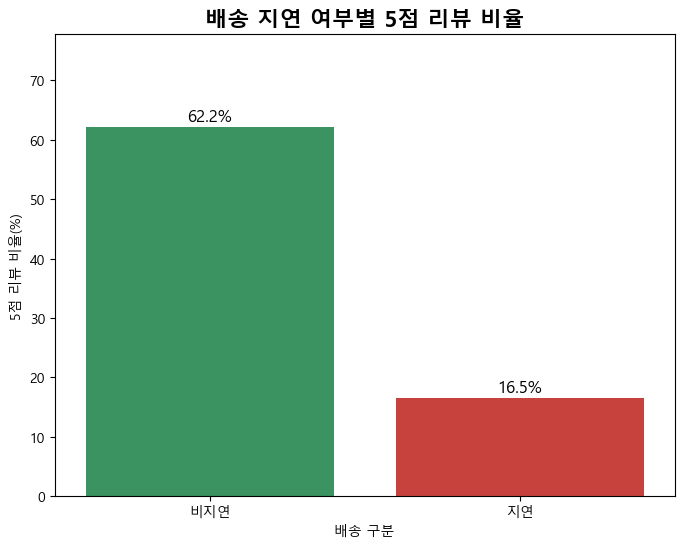

In [28]:
# 시각화: 배송 지연 여부별 5점 리뷰 비율

five_star_plot = five_star_rate.reset_index()
five_star_plot["delay_label"] = five_star_plot["is_delay"].map({
    False: "비지연",
    True: "지연"
})

plt.figure(figsize=(8, 6))

sns.barplot(
    data=five_star_plot,
    x="delay_label",
    y="five_star_rate_pct",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("배송 지연 여부별 5점 리뷰 비율", fontsize=16, weight="bold")
plt.xlabel("배송 구분")
plt.ylabel("5점 리뷰 비율(%)")

for i, row in five_star_plot.iterrows():
    plt.text(
        i,
        row["five_star_rate_pct"] + 1,
        f'{row["five_star_rate_pct"]:.1f}%',
        ha="center",
        fontsize=12
    )

plt.ylim(0, five_star_plot["five_star_rate_pct"].max() * 1.25)
plt.show()

## 결과 해석 예시

카이제곱 독립성 검정 결과 p-value가 0.05보다 작다면, 배송 지연 여부와 5점 리뷰 발생 여부는 서로 독립이 아니라고 판단한다.

즉, 배송 지연 여부에 따라 5점 리뷰 발생 비율이 통계적으로 유의하게 달라진다.

만약 지연 주문의 5점 리뷰 비율이 비지연 주문보다 낮다면, 배송 지연은 긍정적인 고객 경험을 감소시키는 요인으로 해석할 수 있다.

Phi coefficient는 배송 지연 여부와 5점 리뷰 여부 간 관련성의 효과크기를 나타낸다.

따라서 본 결과는 배송 지연이 고객 불만족을 증가시킬 뿐 아니라, 최고 평점인 5점 리뷰를 받을 가능성도 낮춘다는 점을 보여준다.

# 가설 7. 1점과 5점 리뷰는 전체 평균 리뷰점수에 얼마나 영향을 주는가?

## 분석 목적

리뷰점수 분포에서 극단값인 1점과 5점이 전체 평균 리뷰점수에 미치는 영향을 확인한다.

Olist 리뷰점수는 5점 리뷰 비중이 높고, 지연 구간에서는 1점 리뷰 비중이 급격히 증가한다.

따라서 전체 평균 리뷰점수만 볼 경우 고객 불만족 구조가 가려질 수 있다.

## 분석 방법

다음 평균을 비교한다.

1. 전체 리뷰 평균
2. 1점 리뷰 제외 평균
3. 5점 리뷰 제외 평균
4. 1점과 5점 모두 제외 평균

In [29]:
scores = order_df["review_score_mean"].dropna()

sensitivity = pd.DataFrame({
    "case": [
        "전체 평균",
        "1점 제외",
        "5점 제외",
        "1점과 5점 제외"
    ],
    "mean_review_score": [
        scores.mean(),
        scores[scores != 1].mean(),
        scores[scores != 5].mean(),
        scores[~scores.isin([1, 5])].mean()
    ],
    "n": [
        len(scores),
        len(scores[scores != 1]),
        len(scores[scores != 5]),
        len(scores[~scores.isin([1, 5])])
    ]
})

overall_mean = sensitivity.loc[
    sensitivity["case"] == "전체 평균",
    "mean_review_score"
].iloc[0]

sensitivity["diff_from_overall"] = sensitivity["mean_review_score"] - overall_mean

display(sensitivity)

,case,mean_review_score,n,diff_from_overall
0,전체 평균,4.154089,94443,0.000000
1,1점 제외,4.494869,85234,0.340780
2,5점 제외,2.931749,38627,-1.222340
3,1점과 5점 제외,3.536463,29418,-0.617626


C:\Users\yiho1\AppData\Local\Temp\ipykernel_33704\1667437684.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


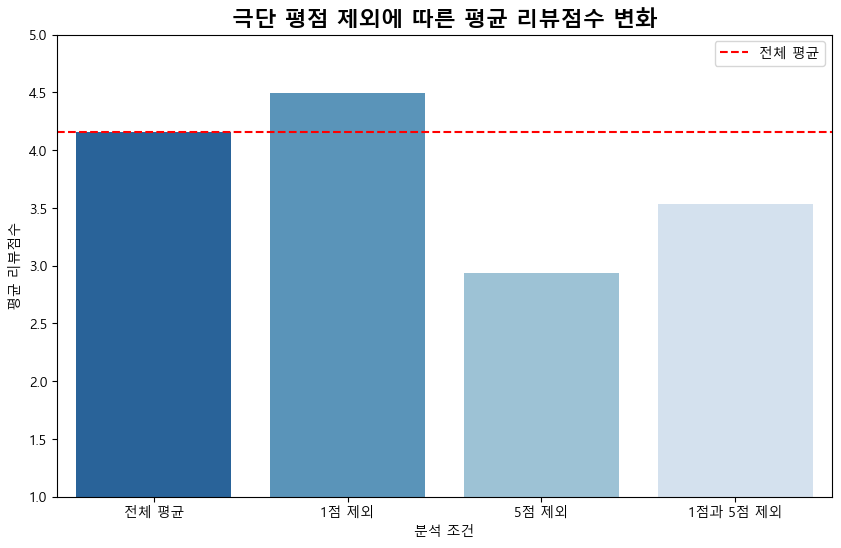

In [30]:
# 시각화: 극단 평점 제외에 따른 평균 리뷰점수 변화

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sensitivity,
    x="case",
    y="mean_review_score",
    palette="Blues_r"
)

plt.axhline(overall_mean, color="red", linestyle="--", label="전체 평균")

plt.title("극단 평점 제외에 따른 평균 리뷰점수 변화", fontsize=16, weight="bold")
plt.xlabel("분석 조건")
plt.ylabel("평균 리뷰점수")
plt.ylim(1, 5)
plt.legend()

plt.show()

# 최종 정리

## 이번 통계검정의 핵심 목적

이번 분석은 물류 허브 선정이나 퍼널/코호트 분석으로 넘어가기 전, 배송 경험과 리뷰점수 간의 관계를 통계적으로 검증하는 사전 분석이다.

기존 시각화에서 확인된 패턴을 바탕으로 다음 통계검정을 수행하였다.

| 검정 주제 | 사용 검정 | 목적 |
|---|---|---|
| 배송 지연일과 리뷰점수 관계 | Spearman 상관분석, 단순 선형회귀 | 지연일 증가가 만족도 하락과 관련 있는지 확인 |
| 지연 여부별 리뷰점수 분포 차이 | 카이제곱 검정 | 지연/비지연 주문의 1~5점 분포 차이 검증 |
| 지연 구간별 리뷰점수 분포 차이 | 카이제곱 검정 | 지연 구간이 길어질수록 분포가 악화되는지 확인 |
| 지연 구간별 평균 리뷰점수 차이 | ANOVA, Kruskal-Wallis | 구간별 평균/중앙값 차이 검증 |
| 1점 리뷰 발생 비율 | 카이제곱 검정 | 배송 지연이 불만족 리뷰를 증가시키는지 확인 |
| 5점 리뷰 발생 비율 | 카이제곱 검정 | 배송 지연이 긍정 리뷰를 감소시키는지 확인 |
| 극단 평점 영향 | 민감도 분석 | 1점/5점 리뷰가 전체 평균에 미치는 영향 확인 |

## 포트폴리오용 해석 문장 예시

배송 예정일 대비 실제 배송일의 차이를 기준으로 리뷰점수 변화를 분석한 결과, 배송 지연일이 증가할수록 평균 리뷰점수는 하락하고 1점 리뷰 비율은 증가하는 패턴이 확인되었다.

특히 배송 예정일을 초과한 이후 리뷰점수 분포가 급격히 부정적으로 이동하며, 지연 배송 주문에서는 5점 리뷰 비율이 감소하고 1점 리뷰 비율이 크게 증가하였다.

이는 고객 만족도 관리에서 단순 평균 배송기간보다 “예정 배송일 준수 여부”가 중요한 지표임을 시사한다.

따라서 이후 물류 허브 선정 분석에서는 평균 배송기간뿐 아니라 지연률, 지연일수, 1점 리뷰 발생률을 함께 고려하는 것이 적절하다.